# Notebook 01 — Preparação do Store Item Demand

## Objetivo

Este notebook realiza a preparação inicial do dataset Store Item Demand para um pipeline de Long Horizon Forecasting.

Cada combinação entre `store` e `item` será considerada uma série temporal independente. As diferentes séries serão utilizadas conjuntamente para treinar um modelo global univariado.

As principais etapas são:

1. carregar os arquivos originais;
2. validar a qualidade dos dados;
3. construir o identificador de cada série;
4. verificar a cobertura temporal;
5. realizar uma análise temporal essencial;
6. definir os períodos de treino, validação e teste;
7. salvar o painel preparado.

A normalização e a construção das janelas serão realizadas no Notebook 02, utilizando somente informações do período de treinamento.

## 1. Configuração

A configuração principal do projeto utiliza:

- frequência diária;
- janela de entrada de 365 dias;
- horizonte principal de 90 dias;
- sazonalidade semanal de sete dias;
- 500 séries formadas pelas combinações entre 10 lojas e 50 itens.

In [14]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path(
    "/kaggle/input/competitions/demand-forecasting-kernels-only"
)

OUTPUT_DIR = Path("/kaggle/working/store_item_lhf")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEQ_LEN = 365
PRED_LEN = 90
SEASONAL_PERIOD = 7
SEED = 42

## 2. Carregamento dos dados

O arquivo `train.csv` contém as vendas observadas entre 2013 e 2017.

O arquivo `test.csv` contém o período futuro da competição, mas não possui a coluna `sales`. Por isso, ele não será utilizado para a avaliação científica dos modelos.

A validação e o teste serão criados a partir de divisões temporais internas do `train.csv`.

In [15]:
train = pd.read_csv(
    DATA_DIR / "train.csv",
    parse_dates=["date"],
)

competition_test = pd.read_csv(
    DATA_DIR / "test.csv",
    parse_dates=["date"],
)

print("Train:", train.shape)
print("Competition test:", competition_test.shape)

display(train.head())
display(competition_test.head())

Train: (913000, 4)
Competition test: (45000, 4)


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


,id,date,store,item
0,0,2018-01-01,1,1
1,1,2018-01-02,1,1
2,2,2018-01-03,1,1
3,3,2018-01-04,1,1
4,4,2018-01-05,1,1


## 3. Auditoria dos dados

Antes da preparação do painel, serão verificadas as seguintes inconsistências:

- valores ausentes;
- registros duplicados;
- datas inválidas;
- vendas negativas;
- quantidade de lojas, itens e séries;
- compatibilidade entre treino e teste da competição.

In [16]:
audit = pd.DataFrame({
    "verificacao": [
        "Valores nulos no treino",
        "Linhas duplicadas",
        "Chaves duplicadas",
        "Vendas negativas",
        "Lojas",
        "Itens",
        "Séries",
    ],
    "resultado": [
        train.isna().sum().sum(),
        train.duplicated().sum(),
        train.duplicated(
            subset=["date", "store", "item"]
        ).sum(),
        (train["sales"] < 0).sum(),
        train["store"].nunique(),
        train["item"].nunique(),
        train[["store", "item"]]
        .drop_duplicates()
        .shape[0],
    ],
})

display(audit)

,verificacao,resultado
0,Valores nulos no treino,0
1,Linhas duplicadas,0
2,Chaves duplicadas,0
3,Vendas negativas,0
4,Lojas,10
5,Itens,50
6,Séries,500


In [17]:
# Remover somente duplicatas completamente idênticas
train = train.drop_duplicates().copy()

# Linhas sem identificação temporal ou da série não são utilizáveis
train = train.dropna(
    subset=["date", "store", "item"]
)

# Não converter vendas ausentes automaticamente em zero
if train["sales"].isna().any():
    raise ValueError(
        "Existem valores ausentes em sales. "
        "É necessário investigar antes de continuar."
    )

if (train["sales"] < 0).any():
    raise ValueError(
        "Foram encontradas vendas negativas."
    )

if train.duplicated(
    subset=["date", "store", "item"]
).any():
    raise ValueError(
        "Existem múltiplas observações para a mesma "
        "data, loja e item."
    )

## 4. Construção do painel temporal

Cada combinação entre loja e item será tratada como uma série temporal.

Será criado o identificador:

\[
\text{series\_id} = (\text{store}, \text{item})
\]

O dataset será mantido no formato longo, com uma observação por série e data.

Esse formato será utilizado posteriormente para:

- calcular a normalização de cada série;
- construir as janelas temporais;
- criar os conjuntos de treino, validação e teste;
- calcular métricas por série.

In [18]:
panel = train.rename(
    columns={"sales": "y"}
).copy()

panel["series_id"] = (
    "store_"
    + panel["store"].astype(str).str.zfill(2)
    + "_item_"
    + panel["item"].astype(str).str.zfill(2)
)

series_mapping = {
    series_id: index
    for index, series_id
    in enumerate(sorted(panel["series_id"].unique()))
}

panel["series_idx"] = (
    panel["series_id"].map(series_mapping)
)

panel = panel[
    [
        "date",
        "series_id",
        "series_idx",
        "store",
        "item",
        "y",
    ]
].sort_values(
    ["series_idx", "date"]
).reset_index(drop=True)

display(panel.head())

,date,series_id,series_idx,store,item,y
0,2013-01-01,store_01_item_01,0,1,1,13
1,2013-01-02,store_01_item_01,0,1,1,11
2,2013-01-03,store_01_item_01,0,1,1,14
3,2013-01-04,store_01_item_01,0,1,1,13
4,2013-01-05,store_01_item_01,0,1,1,10


## 5. Verificação da cobertura temporal

Para construir janelas temporais, cada série deve possuir observações diárias ordenadas e sem lacunas.

Será verificado se todas as séries:

- começam e terminam nas mesmas datas;
- possuem a mesma quantidade de observações;
- não apresentam datas duplicadas;
- não apresentam dias ausentes.

In [19]:
first_date = panel["date"].min()
last_date = panel["date"].max()

expected_dates = pd.date_range(
    first_date,
    last_date,
    freq="D",
)

expected_length = len(expected_dates)

coverage = (
    panel.groupby("series_id")
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        observations=("date", "nunique"),
    )
)

coverage["missing_dates"] = (
    expected_length - coverage["observations"]
)

display(coverage.describe())

assert coverage["missing_dates"].eq(0).all()
assert coverage["start_date"].eq(first_date).all()
assert coverage["end_date"].eq(last_date).all()

print("Todas as séries possuem cobertura diária completa.")

,start_date,end_date,observations,missing_dates
count,500,500,500.0,500.0
mean,2013-01-01 00:00:00,2017-12-31 00:00:00,1826.0,0.0
min,2013-01-01 00:00:00,2017-12-31 00:00:00,1826.0,0.0
25%,2013-01-01 00:00:00,2017-12-31 00:00:00,1826.0,0.0
50%,2013-01-01 00:00:00,2017-12-31 00:00:00,1826.0,0.0
75%,2013-01-01 00:00:00,2017-12-31 00:00:00,1826.0,0.0
max,2013-01-01 00:00:00,2017-12-31 00:00:00,1826.0,0.0
std,NaN,NaN,0.0,0.0


Todas as séries possuem cobertura diária completa.


## 6. Análise temporal essencial

A análise exploratória será limitada aos aspectos que influenciam diretamente a modelagem.

Serão avaliados:

1. comportamento geral da demanda ao longo do tempo;
2. existência de um padrão semanal que justifique o período sazonal igual a sete dias.

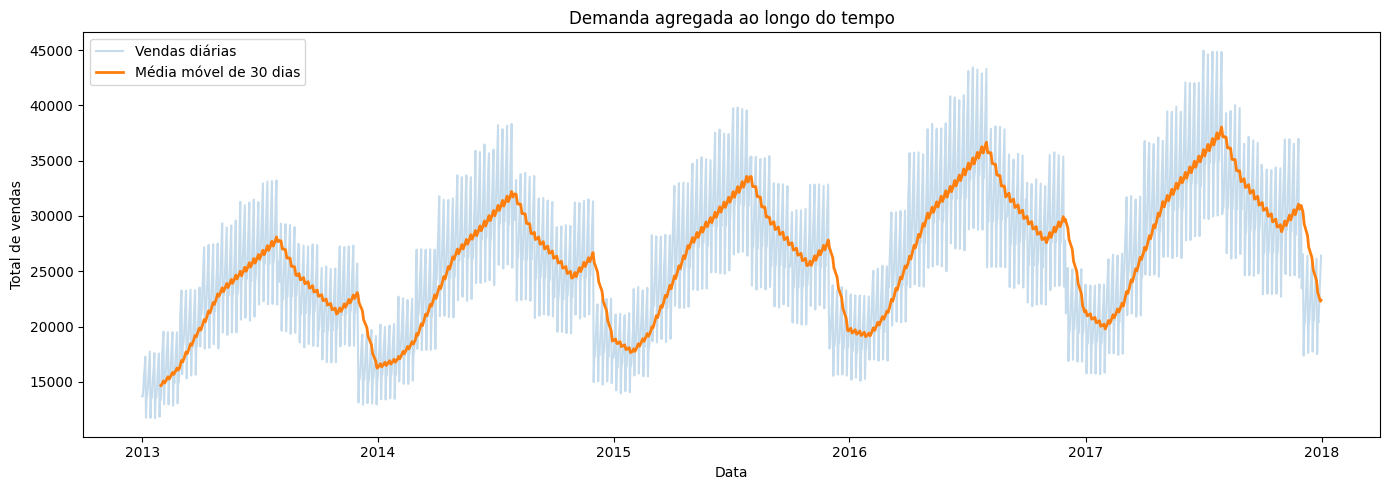

In [20]:
daily_sales = (
    panel.groupby("date", as_index=False)
    .agg(total_sales=("y", "sum"))
)

daily_sales["moving_average_30"] = (
    daily_sales["total_sales"]
    .rolling(30)
    .mean()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales["date"],
    daily_sales["total_sales"],
    alpha=0.25,
    label="Vendas diárias",
)

plt.plot(
    daily_sales["date"],
    daily_sales["moving_average_30"],
    linewidth=2,
    label="Média móvel de 30 dias",
)

plt.title("Demanda agregada ao longo do tempo")
plt.xlabel("Data")
plt.ylabel("Total de vendas")
plt.legend()
plt.tight_layout()
plt.show()

,weekday,mean_sales,weekday_name
0,0,41.429638,Segunda
1,1,48.225908,Terça
2,2,48.368506,Quarta
3,3,51.723218,Quinta
4,4,55.157249,Sexta
5,5,58.662697,Sábado
6,6,62.143333,Domingo


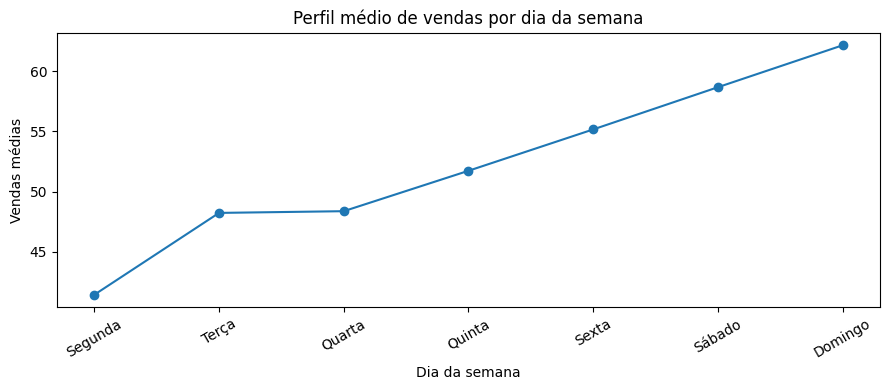

In [21]:
weekly_data = panel.copy()

weekly_data["weekday"] = (
    weekly_data["date"].dt.dayofweek
)

weekday_names = {
    0: "Segunda",
    1: "Terça",
    2: "Quarta",
    3: "Quinta",
    4: "Sexta",
    5: "Sábado",
    6: "Domingo",
}

weekly_profile = (
    weekly_data
    .groupby(["series_id", "weekday"], as_index=False)
    .agg(mean_sales=("y", "mean"))
    .groupby("weekday", as_index=False)
    .agg(mean_sales=("mean_sales", "mean"))
)

weekly_profile["weekday_name"] = (
    weekly_profile["weekday"].map(weekday_names)
)

display(weekly_profile)

plt.figure(figsize=(9, 4))

plt.plot(
    weekly_profile["weekday_name"],
    weekly_profile["mean_sales"],
    marker="o",
)

plt.title("Perfil médio de vendas por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Vendas médias")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [22]:
lag_correlations = []

for series_id, group in panel.groupby("series_id"):
    values = group.sort_values("date")["y"]

    lag_correlations.append({
        "series_id": series_id,
        "lag_1": values.corr(values.shift(1)),
        "lag_7": values.corr(values.shift(7)),
        "lag_14": values.corr(values.shift(14)),
    })

lag_correlations = pd.DataFrame(lag_correlations)

display(
    lag_correlations[
        ["lag_1", "lag_7", "lag_14"]
    ].describe()
)

,lag_1,lag_7,lag_14
count,500.000000,500.000000,500.000000
mean,0.550376,0.700820,0.676816
std,0.076114,0.097721,0.094136
min,0.316394,0.431375,0.374579
25%,0.501661,0.632241,0.614157
50%,0.568121,0.723478,0.697377
75%,0.610900,0.780263,0.751108
max,0.675465,0.845824,0.818166


## 7. Divisão temporal dos dados

Como o arquivo `test.csv` da competição não contém as vendas reais, os períodos de validação e teste serão retirados do final do `train.csv`.

O maior horizonte considerado é de 90 dias.

A divisão será:

- treinamento: todas as observações anteriores à validação;
- validação: 90 dias;
- teste: últimos 90 dias.

A divisão preserva a ordem temporal e impede que informações futuras sejam utilizadas no treinamento.

Os horizontes de 30, 60 e 90 dias utilizarão a mesma origem temporal, considerando respectivamente os primeiros 30, 60 ou 90 dias dos blocos de validação e teste.

In [23]:
MAX_HORIZON = 90

test_end = panel["date"].max()

test_start = (
    test_end
    - pd.Timedelta(days=MAX_HORIZON - 1)
)

validation_end = (
    test_start
    - pd.Timedelta(days=1)
)

validation_start = (
    validation_end
    - pd.Timedelta(days=MAX_HORIZON - 1)
)

train_end = (
    validation_start
    - pd.Timedelta(days=1)
)

split_table = pd.DataFrame({
    "split": [
        "train",
        "validation",
        "test",
    ],
    "start": [
        panel["date"].min(),
        validation_start,
        test_start,
    ],
    "end": [
        train_end,
        validation_end,
        test_end,
    ],
})

split_table["n_days"] = (
    split_table["end"]
    - split_table["start"]
).dt.days + 1

display(split_table)

,split,start,end,n_days
0,train,2013-01-01,2017-07-04,1646
1,validation,2017-07-05,2017-10-02,90
2,test,2017-10-03,2017-12-31,90


In [24]:
panel["split"] = "train"

panel.loc[
    panel["date"].between(
        validation_start,
        validation_end,
    ),
    "split",
] = "validation"

panel.loc[
    panel["date"].between(
        test_start,
        test_end,
    ),
    "split",
] = "test"

display(
    panel.groupby("split")
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        rows=("date", "size"),
        series=("series_id", "nunique"),
    )
)

,start_date,end_date,rows,series
split,,,,
test,2017-10-03,2017-12-31,45000,500
train,2013-01-01,2017-07-04,823000,500
validation,2017-07-05,2017-10-02,45000,500


## 8. Catálogo das séries

Será criado um catálogo contendo as principais características de cada série.

As estatísticas completas serão utilizadas apenas para descrição. Os parâmetros de normalização serão calculados posteriormente utilizando exclusivamente o período de treinamento.

In [25]:
series_catalog = (
    panel.groupby("series_id")
    .agg(
        series_idx=("series_idx", "first"),
        store=("store", "first"),
        item=("item", "first"),
        start_date=("date", "min"),
        end_date=("date", "max"),
        observations=("y", "size"),
        mean_sales=("y", "mean"),
        std_sales=("y", "std"),
        min_sales=("y", "min"),
        max_sales=("y", "max"),
        zero_rate=("y", lambda values: (values == 0).mean()),
    )
    .reset_index()
)

display(series_catalog.head())
display(series_catalog.describe())

,series_id,series_idx,store,item,start_date,end_date,observations,mean_sales,std_sales,min_sales,max_sales,zero_rate
0,store_01_item_01,0,1,1,2013-01-01,2017-12-31,1826,19.971522,6.741022,4,50,0.0
1,store_01_item_02,1,1,2,2013-01-01,2017-12-31,1826,53.148959,15.005779,13,115,0.0
2,store_01_item_03,2,1,3,2013-01-01,2017-12-31,1826,33.208105,10.072529,8,70,0.0
3,store_01_item_04,3,1,4,2013-01-01,2017-12-31,1826,19.956188,6.640618,4,43,0.0
4,store_01_item_05,4,1,5,2013-01-01,2017-12-31,1826,16.612815,5.672102,3,37,0.0


,series_idx,store,item,start_date,end_date,observations,mean_sales,std_sales,min_sales,max_sales,zero_rate
count,500.000000,500.000000,500.000000,500,500,500.0,500.000000,500.000000,500.000000,500.000000,500.000000
mean,249.500000,5.500000,25.500000,2013-01-01 00:00:00,2017-12-31 00:00:00,1826.0,52.250287,14.701935,15.968000,104.812000,0.000001
min,0.000000,1.000000,1.000000,2013-01-01 00:00:00,2017-12-31 00:00:00,1826.0,12.733844,4.731280,0.000000,31.000000,0.000000
25%,124.750000,3.000000,13.000000,2013-01-01 00:00:00,2017-12-31 00:00:00,1826.0,30.964266,9.449078,8.000000,67.000000,0.000000
50%,249.500000,5.500000,25.500000,2013-01-01 00:00:00,2017-12-31 00:00:00,1826.0,50.030942,14.142238,15.000000,101.000000,0.000000
75%,374.250000,8.000000,38.000000,2013-01-01 00:00:00,2017-12-31 00:00:00,1826.0,69.348987,18.857686,23.000000,137.000000,0.000000
max,499.000000,10.000000,50.000000,2013-01-01 00:00:00,2017-12-31 00:00:00,1826.0,112.638007,29.676051,44.000000,231.000000,0.000548
std,144.481833,2.875158,14.445322,NaN,NaN,0.0,24.062536,5.976603,9.840969,43.919318,0.000024


## 9. Salvamento dos dados preparados

O painel limpo e os metadados serão salvos para utilização no Notebook 02.

O Notebook 02 será responsável por:

- calcular os parâmetros de normalização com base apenas no treino;
- criar os resíduos sazonais;
- construir as janelas de entrada e saída;
- preparar os datasets e dataloaders.

In [26]:
panel.to_parquet(
    OUTPUT_DIR / "panel_prepared.parquet",
    index=False,
)

series_catalog.to_parquet(
    OUTPUT_DIR / "series_catalog.parquet",
    index=False,
)

split_config = {
    "train_end": str(train_end.date()),
    "validation_start": str(validation_start.date()),
    "validation_end": str(validation_end.date()),
    "test_start": str(test_start.date()),
    "test_end": str(test_end.date()),
    "seq_len": SEQ_LEN,
    "pred_len": PRED_LEN,
    "seasonal_period": SEASONAL_PERIOD,
}

with open(
    OUTPUT_DIR / "split_config.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        split_config,
        file,
        indent=4,
    )

print("Arquivos salvos em:", OUTPUT_DIR)

Arquivos salvos em: /kaggle/working/store_item_lhf
